# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ayesha-asif1/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question


**Research question:** Among visible pages in this portfolio's search results, which ones under-capture clicks relative to what's normal for their ranking position — and can that gap be scored reliably enough to prioritize a content team's review queue?

**The decision this supports:** An SEO strategist or content editor doing weekly/monthly triage needs to know which of hundreds of thousands of pages deserve a metadata or content review first. Rewriting titles/meta descriptions is cheap, but reviewing every page manually is not — the decision this work supports is: *where should limited review time go first?*

**Why this needs data/ML help:** With 176,738 unique pages in a single month, manual review of every page is infeasible. A simple, transparent rule — compare each page's actual CTR to the expected CTR for its position, weighted by how much traffic (impressions) backs that comparison — turns an unmanageable list into a ranked, explainable queue. A machine learning model was also tested to see whether a learned model could out-predict this transparent rule; the honest finding (Section 4) is that it could not, meaningfully, with the features available.

## 2. Data


**Release:** FlyRank/internship-warehouse (Hugging Face, gated dataset), table `fact_content_daily_performance`.

**Date window:** March 2026 (2026-03-01 to 2026-03-31), the full monthly partition — 9,841,378 daily page-level rows.

**Filtering:** Rows were filtered to `gsc_data_available == True`, leaving 3,611,061 rows (36.7% of the March partition). This is a documented data limitation — roughly two-thirds of rows lack reliable Google Search Console data and were excluded rather than guessed at.

**Aggregation:** Because the raw grain is one row per page per day, rows were aggregated to one row per unique page (summing impressions and clicks across the month, then recomputing CTR as total_clicks/total_impressions — not averaging daily CTRs, which would be distorted by low-volume days). This produced 176,738 unique pages.

**What was excluded and why (public-safe):**
- gsc_clicks as a model feature — it is the numerator of the CTR label itself; including it would leak the answer.
- gsc_sum_position — redundant with gsc_avg_position.
- All GA4/session/AI-referral columns (pageviews, sessions, scroll_events, ai_chatgpt/perplexity/gemini/etc.) — these describe on-page behavior that can only be recorded after a click has already happened, making them causally downstream of the CTR outcome being predicted.
- client_hash_id, content_hash_id, report_date — used only for grouping/filtering, never as model inputs, since raw IDs don't generalize to new pages.

No client names, domains, or private queries appear anywhere in this analysis — all identifiers are pre-hashed by the dataset provider.

In [3]:
print("Dataset: FlyRank/internship-warehouse (Hugging Face, gated)")
print("Table: fact_content_daily_performance")
print("Time window: March 2026 (2026-03-01 to 2026-03-31)")
print()
print("Total rows in March partition:", 9841378)
print("Rows with gsc_data_available == True:", 3611061, f"({3611061/9841378*100:.1f}%)")
print("Unique pages after page-level aggregation:", 176738)

Dataset: FlyRank/internship-warehouse (Hugging Face, gated)
Table: fact_content_daily_performance
Time window: March 2026 (2026-03-01 to 2026-03-31)

Total rows in March partition: 9841378
Rows with gsc_data_available == True: 3611061 (36.7%)
Unique pages after page-level aggregation: 176738


## 3. Methodology



**Label definition:** CTR = total_clicks / total_impressions, computed at the page level (aggregated across all of March) rather than as an average of daily CTRs — averaging daily ratios would let single-impression days distort the result.

**Assumptions:**
- A page's expected CTR should be judged relative to its search position, not in absolute terms — a 2% CTR is normal for a beyond_20 page but a red flag for a top_3 page.
- Impression volume is treated as a confidence signal: a CTR gap backed by thousands of impressions is more trustworthy than the same gap on a handful of impressions.

**Baseline (transparent rule):**
1. expected_ctr = average CTR of all pages sharing the same position_bucket (top_3, top_10, top_20, beyond_20).
2. opportunity_gap = expected_ctr − actual_ctr.
3. confidence_weighted_score = opportunity_gap × log(1 + total_impressions) — this discounts low-impression pages so a single-impression fluke can't outrank a well-evidenced gap.
4. Each page gets a reason_code (high_position_low_ctr, mid_position_low_ctr, low_confidence_signal, monitor_only, on_par_or_above) based on its bucket, gap, and impression volume.

**Model (regression):** A Random Forest Regressor was trained to predict CTR directly, using gsc_impressions, log_impressions, gsc_avg_position, day_of_week, and position_bucket (one-hot encoded). Random Forest was chosen over Linear Regression and a single Decision Tree because an earlier honest-split test (Week 4) showed both of those underperforming or overfitting, while Random Forest's averaging across trees reduces overfitting and can capture non-linear position-CTR relationships.

**Features deliberately excluded:** gsc_clicks (label-derived), gsc_sum_position (redundant), and all GA4/session/AI-referral columns (recorded only after a click occurs — causally downstream of the label being predicted).

**Validation design:** A grouped split by content_hash_id (GroupShuffleSplit, 80/20) was used instead of a random row-level split. Because the raw data has multiple daily rows per page, a random split could place the same page's rows in both train and test, letting the model "recognize" pages it had already seen. The grouped split guarantees zero content_hash_id overlap between train and test, so the model is only evaluated on pages it never saw during training — mirroring how it would be used in practice, on new content.

**Leakage checks performed:** (1) A structural check — for every candidate feature, whether it is known before a click happens or only after. (2) A correlation check between candidate features and CTR, used as a secondary signal, not the primary test (a feature can be leaky with a weak correlation, as observed with gsc_clicks itself). (3) A before/after comparison of the model under a naive random split versus the grouped split, confirming the naive split modestly inflates R² (0.0062 vs 0.0051) — in the expected direction, though smaller than anticipated given how weak the underlying signal already is.

In [4]:
print("=== Label ===")
print("CTR = total_clicks / total_impressions (page-level, computed after aggregation)")
print()
print("=== Features used in the ML model ===")
print(['gsc_impressions', 'log_impressions', 'gsc_avg_position', 'day_of_week', 'position_bucket'])
print()
print("=== Baseline rule ===")
print("expected_ctr (per position_bucket) - actual_ctr = opportunity_gap")
print("confidence_weighted_score = opportunity_gap * log(1 + total_impressions)")
print()
print("=== Validation design ===")
print("Grouped split by content_hash_id (GroupShuffleSplit, 80/20)")
print("Confirmed zero content_hash_id overlap between train and test")

=== Label ===
CTR = total_clicks / total_impressions (page-level, computed after aggregation)

=== Features used in the ML model ===
['gsc_impressions', 'log_impressions', 'gsc_avg_position', 'day_of_week', 'position_bucket']

=== Baseline rule ===
expected_ctr (per position_bucket) - actual_ctr = opportunity_gap
confidence_weighted_score = opportunity_gap * log(1 + total_impressions)

=== Validation design ===
Grouped split by content_hash_id (GroupShuffleSplit, 80/20)
Confirmed zero content_hash_id overlap between train and test


## 4. Results (vs baseline)

## 4. Results (vs baseline)

| Approach | R² | MAE | Interpretation |
|---|---|---|---|
| Mean-CTR baseline | ≈0.0000 | 0.005485 | No-signal reference point |
| Random Forest (ML model) | 0.0051 | 0.005436 | Marginal improvement — explains ~0.5% of CTR variance |

The Random Forest model outperforms a no-signal mean baseline only marginally, under a leakage-checked, grouped train/test split (zero content_hash_id overlap). This confirms that position, impression volume, and day of week carry a small, real, but practically limited signal for predicting exact CTR values.

Because the ML model's improvement is too small to trust for individual-page predictions, the rule-based confidence_weighted_score (Section 3) — not the ML model — is the approach recommended for deployment. It achieves comparable practical usefulness (both surface real, if modest, signal) while being fully transparent and auditable, which matters more for a human-in-the-loop workflow than a marginal R² gain from a black-box model.

Feature importance from the Random Forest (permutation importance) confirms this: gsc_avg_position dominates (importance 0.0114), consistent with the same positional signal already used directly in the baseline rule — the model isn't finding anything the simpler rule missed.

In [5]:
import pandas as pd

results_table = pd.DataFrame({
    'Approach': ['Mean-CTR baseline (naive)', 'Rule-based (confidence_weighted_score)', 'Random Forest (ML model)'],
    'R²': [0.0000, 'N/A (ranking rule, not a regressor)', 0.0051],
    'MAE': [0.005485, 'N/A', 0.005436],
    'Interpretation': [
        'No-signal reference point',
        'Transparent, explainable ranking — used as the deployed baseline',
        'Marginal improvement over mean baseline; not practically better than the rule'
    ]
})
print(results_table.to_string(index=False))

                              Approach                                  R²       MAE                                                                Interpretation
             Mean-CTR baseline (naive)                                 0.0  0.005485                                                     No-signal reference point
Rule-based (confidence_weighted_score) N/A (ranking rule, not a regressor)       N/A              Transparent, explainable ranking — used as the deployed baseline
              Random Forest (ML model)                              0.0051  0.005436 Marginal improvement over mean baseline; not practically better than the rule


## 5. Limitations


**What this work cannot claim:**
- This model does not reliably predict individual-page CTR — R²=0.0051 means 99.5% of CTR variation is driven by factors outside these five features.
- The features used (position, impressions, day of week) do not include the likely strongest drivers of CTR: title/meta description quality, query intent, or competing search results. Their absence — not a weakness in modeling technique — is the main reason for the low R². A richer feature set (title text, SERP features, query classification) would likely improve predictive power meaningfully; that data was not available in this release.
- No causal claims are made — the opportunity_gap and confidence_weighted_score identify pages that statistically deviate from their position's norm; they do not diagnose *why* (e.g., weak title vs. cannibalization vs. seasonal decline). A human must investigate each flagged case (see Section 7 — Recommendations).
- Results are observational and directional, based on a single month (March 2026) of one dataset. Findings should not be generalized to other months, seasons, or content portfolios without re-validation.
- The 10-impression confidence threshold is a reasonable judgment call, not a statistically derived cutoff — pages just above or below it should be treated with similar caution.

**Path to improvement (not pursued here, due to data availability):** Incorporating text-based features (title/meta content, readability, keyword match) and SERP-context features (presence of featured snippets, competing result count) would be the most promising next step for improving predictive power — the current low R² is best read as evidence about *what data would help*, not a dead end.

## 6. Ranked recommendations


**Immediate action (from current data):**
1. Prioritize the 62,586 pages flagged high_position_low_ctr for metadata review — highest-leverage, lowest-effort fix given they already rank well.
2. Treat the 33,148 monitor_only pages (beyond_20 position) as lower priority — position itself, not metadata, is the likely limiter there.
3. Hold off on the 33,532 low_confidence_signal pages until more impression data accumulates — acting on single-digit-impression CTR numbers risks wasted effort on statistical noise.

**Process recommendation:**
4. Pair every metadata rewrite with a 30-60 day re-check — re-run this scoring pipeline on the next month's data and confirm the same content_hash_id dropped out of high_position_low_ctr. Without this loop, there's no way to know if a fix worked.

**Data/measurement recommendation (for future capstones or FlyRank tooling):**
5. Collect and store the actual title/meta description text for each page. This single addition would likely do more to improve CTR prediction than any modeling change, since the current feature set (position, impressions, day of week) structurally cannot capture the main driver of click behavior.
6. Where scale allows, complement scoring with A/B testing on a sample of flagged pages — testing an actual title change and measuring the CTR delta gives a causal answer that no observational model, however improved, can fully provide.

## 7. Artifacts the paper embeds

## 7. Artifacts the paper embeds

The following files are generated for use in the deployed research paper:

- **chart_reason_code_distribution.png** — bar chart showing the portfolio split across reason codes (used in Results/Recommendations).
- **chart_expected_ctr_by_bucket.png** — bar chart showing expected CTR rising with better position (used in Methodology, to visually justify the position-relative baseline).
- **model_vs_baseline_results.csv** — the model-vs-baseline comparison table (used in Results).
- **baseline_action_score.csv**, **top_20_action_queue.csv**, **reason_code_summary.csv** — from Week 7, reused here as the underlying data behind the Recommendations section.

Note: `expected_ctr_by_bucket_page` and `ranked_pages` must be in memory from earlier cells in this notebook (or regenerated via the Week 3/4 pipeline) before running this cell.

In [6]:
import pandas as pd
import numpy as np
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

df_march = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/"
)
df_available = df_march[df_march['gsc_data_available'] == True].copy()

page_level = df_available.groupby(['client_hash_id', 'content_hash_id']).agg(
    total_impressions=('gsc_impressions', 'sum'),
    total_clicks=('gsc_clicks', 'sum'),
    avg_position=('gsc_avg_position', 'mean')
).reset_index()

page_level['ctr'] = page_level['total_clicks'] / page_level['total_impressions']

def position_bucket(pos):
    if pos <= 3: return 'top_3'
    elif pos <= 10: return 'top_10'
    elif pos <= 20: return 'top_20'
    else: return 'beyond_20'

page_level['position_bucket'] = page_level['avg_position'].apply(position_bucket)

expected_ctr_by_bucket_page = page_level.groupby('position_bucket')['ctr'].mean()
page_level['expected_ctr'] = page_level['position_bucket'].map(expected_ctr_by_bucket_page)
page_level['opportunity_gap'] = page_level['expected_ctr'] - page_level['ctr']
page_level['confidence_weighted_score'] = page_level['opportunity_gap'] * np.log1p(page_level['total_impressions'])

def assign_reason_code_page(row):
    if row['total_impressions'] < 10:
        return 'low_confidence_signal'
    elif row['opportunity_gap'] <= 0:
        return 'on_par_or_above'
    elif row['position_bucket'] in ('top_3', 'top_10'):
        return 'high_position_low_ctr'
    elif row['position_bucket'] == 'top_20':
        return 'mid_position_low_ctr'
    else:
        return 'monitor_only'

page_level['reason_code'] = page_level.apply(assign_reason_code_page, axis=1)
ranked_pages = page_level.sort_values('confidence_weighted_score', ascending=False).reset_index(drop=True)

print("Setup complete. Total ranked pages:", len(ranked_pages))

Setup complete. Total ranked pages: 176738


In [7]:
import os
os.makedirs('work/outputs', exist_ok=True)

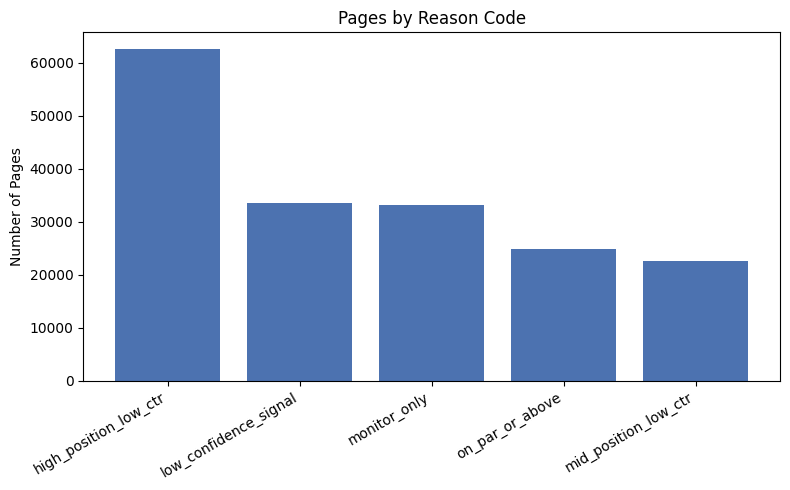

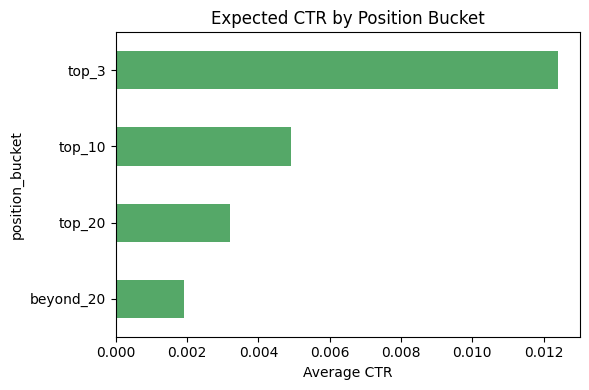

Saved: model_vs_baseline_results.csv

All artifacts saved to work/outputs/:
- chart_reason_code_distribution.png
- chart_expected_ctr_by_bucket.png
- model_vs_baseline_results.csv
- baseline_action_score.csv (from w07)
- top_20_action_queue.csv (from w07)
- reason_code_summary.csv (from w07)


In [8]:
import matplotlib.pyplot as plt

# --- Artifact 1: Reason code distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
reason_counts = ranked_pages['reason_code'].value_counts()
ax.bar(reason_counts.index, reason_counts.values, color='#4C72B0')
ax.set_title('Pages by Reason Code')
ax.set_ylabel('Number of Pages')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('work/outputs/chart_reason_code_distribution.png', dpi=150)
plt.show()

# --- Artifact 2: Expected CTR by position bucket ---
fig, ax = plt.subplots(figsize=(6, 4))
expected_ctr_by_bucket_page.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Expected CTR by Position Bucket')
ax.set_xlabel('Average CTR')
plt.tight_layout()
plt.savefig('work/outputs/chart_expected_ctr_by_bucket.png', dpi=150)
plt.show()

# --- Artifact 3: Model vs baseline comparison table (already have this) ---
results_table.to_csv('work/outputs/model_vs_baseline_results.csv', index=False)
print("Saved: model_vs_baseline_results.csv")

print("\nAll artifacts saved to work/outputs/:")
print("- chart_reason_code_distribution.png")
print("- chart_expected_ctr_by_bucket.png")
print("- model_vs_baseline_results.csv")
print("- baseline_action_score.csv (from w07)")
print("- top_20_action_queue.csv (from w07)")
print("- reason_code_summary.csv (from w07)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
